# 01 — SAM 3 text-prompt inference

**Objetivo:** primera inferencia real con SAM 3 sobre frames de nuestro dataset usando **prompts de texto** (open vocabulary).

**Flujo:**
1. Carga modelo SAM 3 (`facebook/sam3`) en CPU, dtype `bfloat16` para ahorrar RAM
2. Extrae **10 frames** evenly spaced del primer video del dataset
3. Aplica 3 prompts de texto: `"orange ball"`, `"robot"`, `"green floor"`
4. Visualiza máscaras sobre los frames (grid)

**Tiempo estimado:** ~5 min en CPU (10 frames × 3 prompts × ~9s).

**Notas clave SAM 3:**
- Con prompt de texto detecta TODAS las instancias del concepto en la imagen.
- Output trae `object_ids` (lista de N detecciones) y `obj_id_to_mask` (dict con máscara por instancia).
- `obj_id_to_score` es la confianza del decoder (no es IoU calculado nosotros).
- 1 prompt por inferencia (el modelo internamente puede devolver múltiples instancias del mismo concepto).
- En GPU pod (5090) esto corre ~50× más rápido.

## 1. Imports + paths

In [1]:
import os, sys, time
from pathlib import Path
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import decord
import cv2
from transformers import AutoProcessor, AutoModel

WORKSPACE = Path('/workspace')
REPO = WORKSPACE / 'FutBotMX-UAQTeam'
SAM3_PATH = REPO / 'assets' / 'sam3'
DATA = REPO / 'data' / 'raw'  # symlink a /workspace/Meta_Glasses

print('Python:', sys.version.split()[0])
print('torch :', torch.__version__)
print('SAM 3 :', SAM3_PATH)
print('Data  :', DATA.resolve())

Python: 3.11.13
torch : 2.11.0+cu128
SAM 3 : /workspace/FutBotMX-UAQTeam/assets/sam3
Data  : /workspace/Meta_Glasses


## 2. Cargar SAM 3

Usamos `bfloat16` para ahorrar RAM (mitad que float32). En CPU pod con 16 GB RAM esto ocupa ~3.5 GB.

In [2]:
t0 = time.time()
processor = AutoProcessor.from_pretrained(str(SAM3_PATH))
model = AutoModel.from_pretrained(
    str(SAM3_PATH),
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
).to('cuda')
model.eval()
print(f'Carga en {time.time()-t0:.1f}s')
print(f'Clase     : {type(model).__name__}')
print(f'Dispositivo: {next(model.parameters()).device}')
print(f'dtype     : {next(model.parameters()).dtype}')
print(f'Params    : {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Carga en 22.2s
Clase     : Sam3VideoModel
Dispositivo: cuda:0
dtype     : torch.bfloat16
Params    : 859.9M


## 3. Extraer 10 frames de un video

Tomamos el primer video de `17Abril/Cámaras/` y sacamos **10 frames evenly spaced** desde el inicio hasta el final. Esto da cobertura temporal sin saturar el CPU.

In [3]:
VIDEO_PATH = sorted((DATA / '17Abril' / 'Cámaras').glob('*.MOV'))[0]
print('Video:', VIDEO_PATH.name)

vr = decord.VideoReader(str(VIDEO_PATH))
total_frames = len(vr)
fps = vr.get_avg_fps()
print(f'  Frames totales: {total_frames}')
print(f'  FPS: {fps:.1f}')
print(f'  Duración: {total_frames/fps:.1f} s')

N_FRAMES = 10
FRAME_INDICES = list(np.linspace(0, total_frames - 1, N_FRAMES, dtype=int))
frames_np = vr.get_batch(FRAME_INDICES).asnumpy()  # (N, H, W, 3)
frames_pil = [Image.fromarray(f) for f in frames_np]
print(f'\n{N_FRAMES} frames extraídos, índices: {FRAME_INDICES}')
print(f'Shape por frame: {frames_np[0].shape}')

Video: IMG_9779.MOV


  Frames totales: 1044
  FPS: 30.0
  Duración: 34.8 s



10 frames extraídos, índices: [np.int64(0), np.int64(115), np.int64(231), np.int64(347), np.int64(463), np.int64(579), np.int64(695), np.int64(811), np.int64(927), np.int64(1043)]
Shape por frame: (1080, 1920, 3)


## 4. Visualizar los 10 frames originales (grid 2×5)

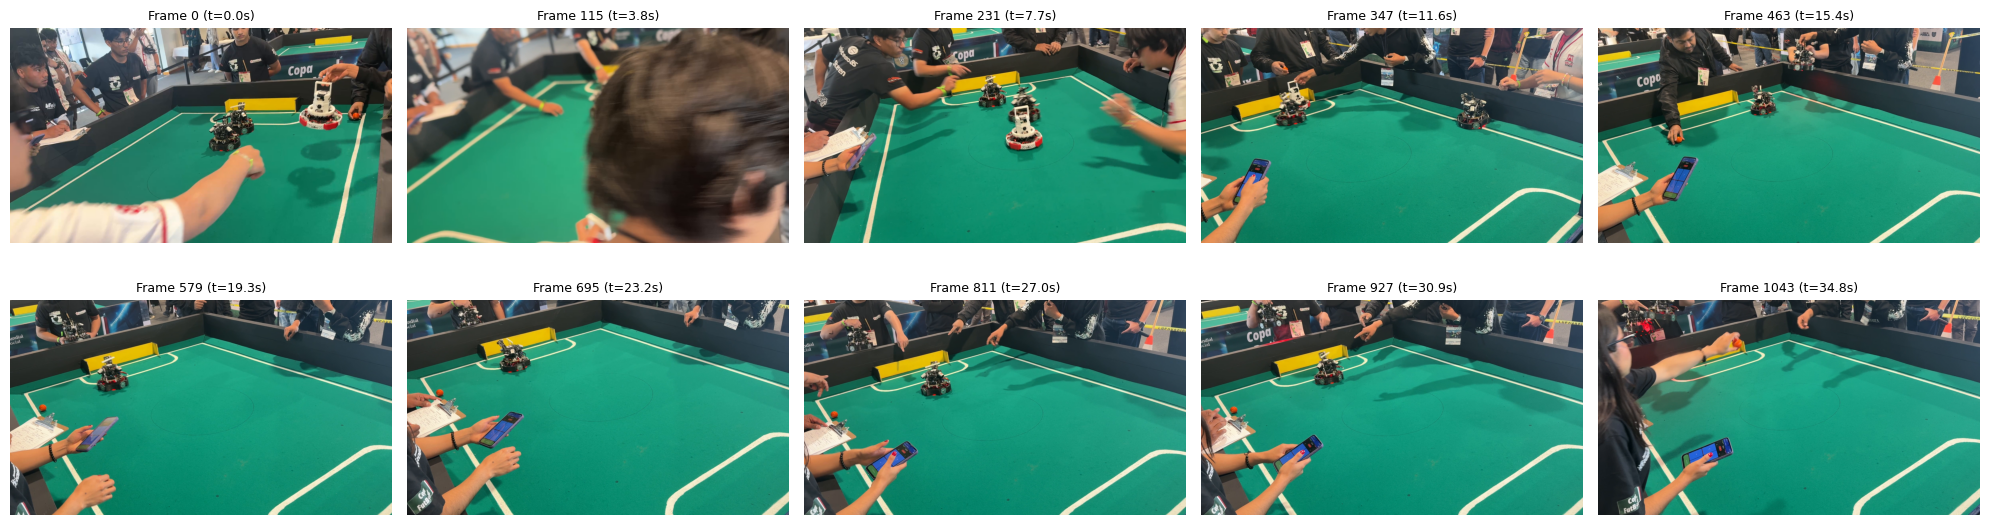

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for ax, img, idx in zip(axes.flat, frames_pil, FRAME_INDICES):
    ax.imshow(img)
    ax.set_title(f'Frame {idx} (t={idx/fps:.1f}s)', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Helper de inferencia

**API SAM 3 con texto = inference session pattern:**
1. `init_video_session([imagen])` — estado de inferencia (aunque sea 1 frame, se llama "video")
2. `add_text_prompt(session, text="...")` — agrega prompt
3. `model(inference_session=session, frame_idx=0)` — forward
4. Output → `obj_id_to_mask` (dict), `object_ids` (lista), `obj_id_to_score` (dict)

**1 prompt por inferencia.** Si quieres 3 clases (ball, robot, floor) son 3 forward passes.

`obj_id_to_score` no es IoU — es el score del decoder (confianza categoría + alignment text-mask).

In [5]:
def mask_from_logits(logits, W0, H0):
    """Logits del modelo (~288x288) -> upscale BILINEAR a full-res -> threshold.
    Borde suave sub-pixel (no escalones NEAREST). NMS/hole-fill/sprinkle lo hace la lib `kernels` en origen."""
    lo = logits.astype(np.float32)
    if lo.shape != (H0, W0):
        lo = cv2.resize(lo, (W0, H0), interpolation=cv2.INTER_LINEAR)
    return lo > 0.0

@torch.no_grad()
def segment_with_text(image: Image.Image, text: str):
    """Lista de (obj_id, mask_bool, score). Upscale bilinear de logits + post-proc kernels."""
    session = processor.init_video_session(
        video=[image],
        inference_device='cuda',
        dtype=torch.bfloat16,
    )
    session = processor.add_text_prompt(session, text=text)
    out = model(inference_session=session, frame_idx=0)

    W0, H0 = image.size
    results = []
    for obj_id in out.object_ids:
        score = float(out.obj_id_to_score.get(obj_id, 0.0))
        m = out.obj_id_to_mask[obj_id].detach().cpu().float().numpy()
        if m.ndim == 4:
            m = m[0, 0]
        elif m.ndim == 3:
            m = m[0]
        results.append((int(obj_id), mask_from_logits(m, W0, H0), score))
    return results


## 6. Prompts de texto

**Resultados del probe de prompts pa' la cancha (RoboCup green plastic):**

| Prompt | Detecciones | Score |
|---|---|---|
| `"green floor"` | 2 | **0.945** ✅ ganador |
| `"green playing surface"` | 2 | 0.922 |
| `"green court"` | 2 | 0.910 |
| `"green ground"` | 2 | 0.898 |
| `"playing field"` | 2 | 0.836 |
| `"green area"` | 2 | 0.816 |
| `"RoboCup field"` | 2 | 0.645 |
| `"green carpet"` | 2 | 0.555 |
| `"green field"` | **0** | — |
| `"soccer field"` | **0** | — |
| `"grass"` | **0** | — |
| `"green mat"` | **0** | — |
| `"green plastic surface"` | **0** | — |

SAM 3 reconoce **piso verde** semánticamente; no asocia automático con contexto deportivo. Usamos `"green floor"`.

In [6]:
PROMPTS = [
    'orange ball',
    'robot',
    'green playing surface with lines',
    'yellow zone',
    'dark blue rectangle',  # porteria azul (mejor prompt por score, ver nb 09)
]
print('Prompts (1 inferencia c/u):')
for p in PROMPTS:
    print(f'  - "{p}"')

Prompts (1 inferencia c/u):
  - "orange ball"
  - "robot"
  - "green playing surface with lines"
  - "yellow zone"
  - "dark blue rectangle"


## 7. Inferencia — 10 frames × 3 prompts = 30 forwards

~9s/forward en CPU → ~4.5 min total. Progreso en stdout.

In [7]:
# results_grid[(frame_idx, prompt)] = list of (obj_id, mask_bool, score)
results_grid = {}
t_start = time.time()
for fi, img in enumerate(frames_pil):
    for prompt in PROMPTS:
        t0 = time.time()
        res = segment_with_text(img, prompt)
        dt = time.time() - t0
        n_inst = len(res)
        best_score = max((s for _, _, s in res), default=0.0)
        print(f'  f={fi:2d} frame={FRAME_INDICES[fi]:4d} prompt="{prompt:12s}" → {n_inst} inst, max={best_score:.3f}, {dt:.1f}s')
        results_grid[(fi, prompt)] = res
print(f'\nTotal: {time.time()-t_start:.1f}s para 30 inferencias')

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

  f= 0 frame=   0 prompt="orange ball " → 1 inst, max=0.863, 5.7s


  f= 0 frame=   0 prompt="robot       " → 3 inst, max=0.961, 0.4s


  f= 0 frame=   0 prompt="green playing surface with lines" → 2 inst, max=0.953, 0.2s


  f= 0 frame=   0 prompt="yellow zone " → 2 inst, max=0.914, 0.2s


...

  f= 9 frame=1043 prompt="orange ball " → 1 inst, max=0.586, 0.2s


  f= 9 frame=1043 prompt="robot       " → 1 inst, max=0.656, 0.2s


  f= 9 frame=1043 prompt="green playing surface with lines" → 1 inst, max=0.969, 0.2s


  f= 9 frame=1043 prompt="yellow zone " → 2 inst, max=0.793, 0.2s


  f= 9 frame=1043 prompt="dark blue rectangle" → 6 inst, max=0.762, 0.3s

Total: 17.6s para 30 inferencias


## 8. Estadísticas — cuántas instancias por prompt a lo largo del video

In [8]:
print(f"{'Prompt':15s}  {'min':>5s} {'max':>5s} {'avg':>6s}  {'inst per frame':s}")
print('-' * 65)
for prompt in PROMPTS:
    counts = [len(results_grid[(fi, prompt)]) for fi in range(len(frames_pil))]
    scores = []
    for fi in range(len(frames_pil)):
        for _, _, s in results_grid[(fi, prompt)]:
            scores.append(s)
    avg = np.mean(counts)
    avg_score = np.mean(scores) if scores else 0.0
    counts_str = ' '.join(f'{c:2d}' for c in counts)
    print(f'{prompt:15s}  {min(counts):>5d} {max(counts):>5d} {avg:>6.2f}  [{counts_str}]  avg_score={avg_score:.2f}')

Prompt             min   max    avg  inst per frame
-----------------------------------------------------------------
orange ball          0     1   0.80  [ 1  0  0  1  1  1  1  1  1  1]  avg_score=0.81
robot                0     3   1.90  [ 3  0  3  2  2  2  2  2  2  1]  avg_score=0.89
green playing surface with lines      1     2   1.80  [ 2  1  2  2  2  2  2  2  2  1]  avg_score=0.87
yellow zone          1     4   2.60  [ 2  1  3  2  3  3  2  4  4  2]  avg_score=0.81
dark blue rectangle      0     6   1.60  [ 0  0  0  1  5  0  4  0  0  6]  avg_score=0.68


## 9. Visualización — grid 10×3 (frames × prompts)

Cada celda: frame con máscara overlay. Si SAM 3 detectó varias instancias del prompt, se dibujan con colores distintos.

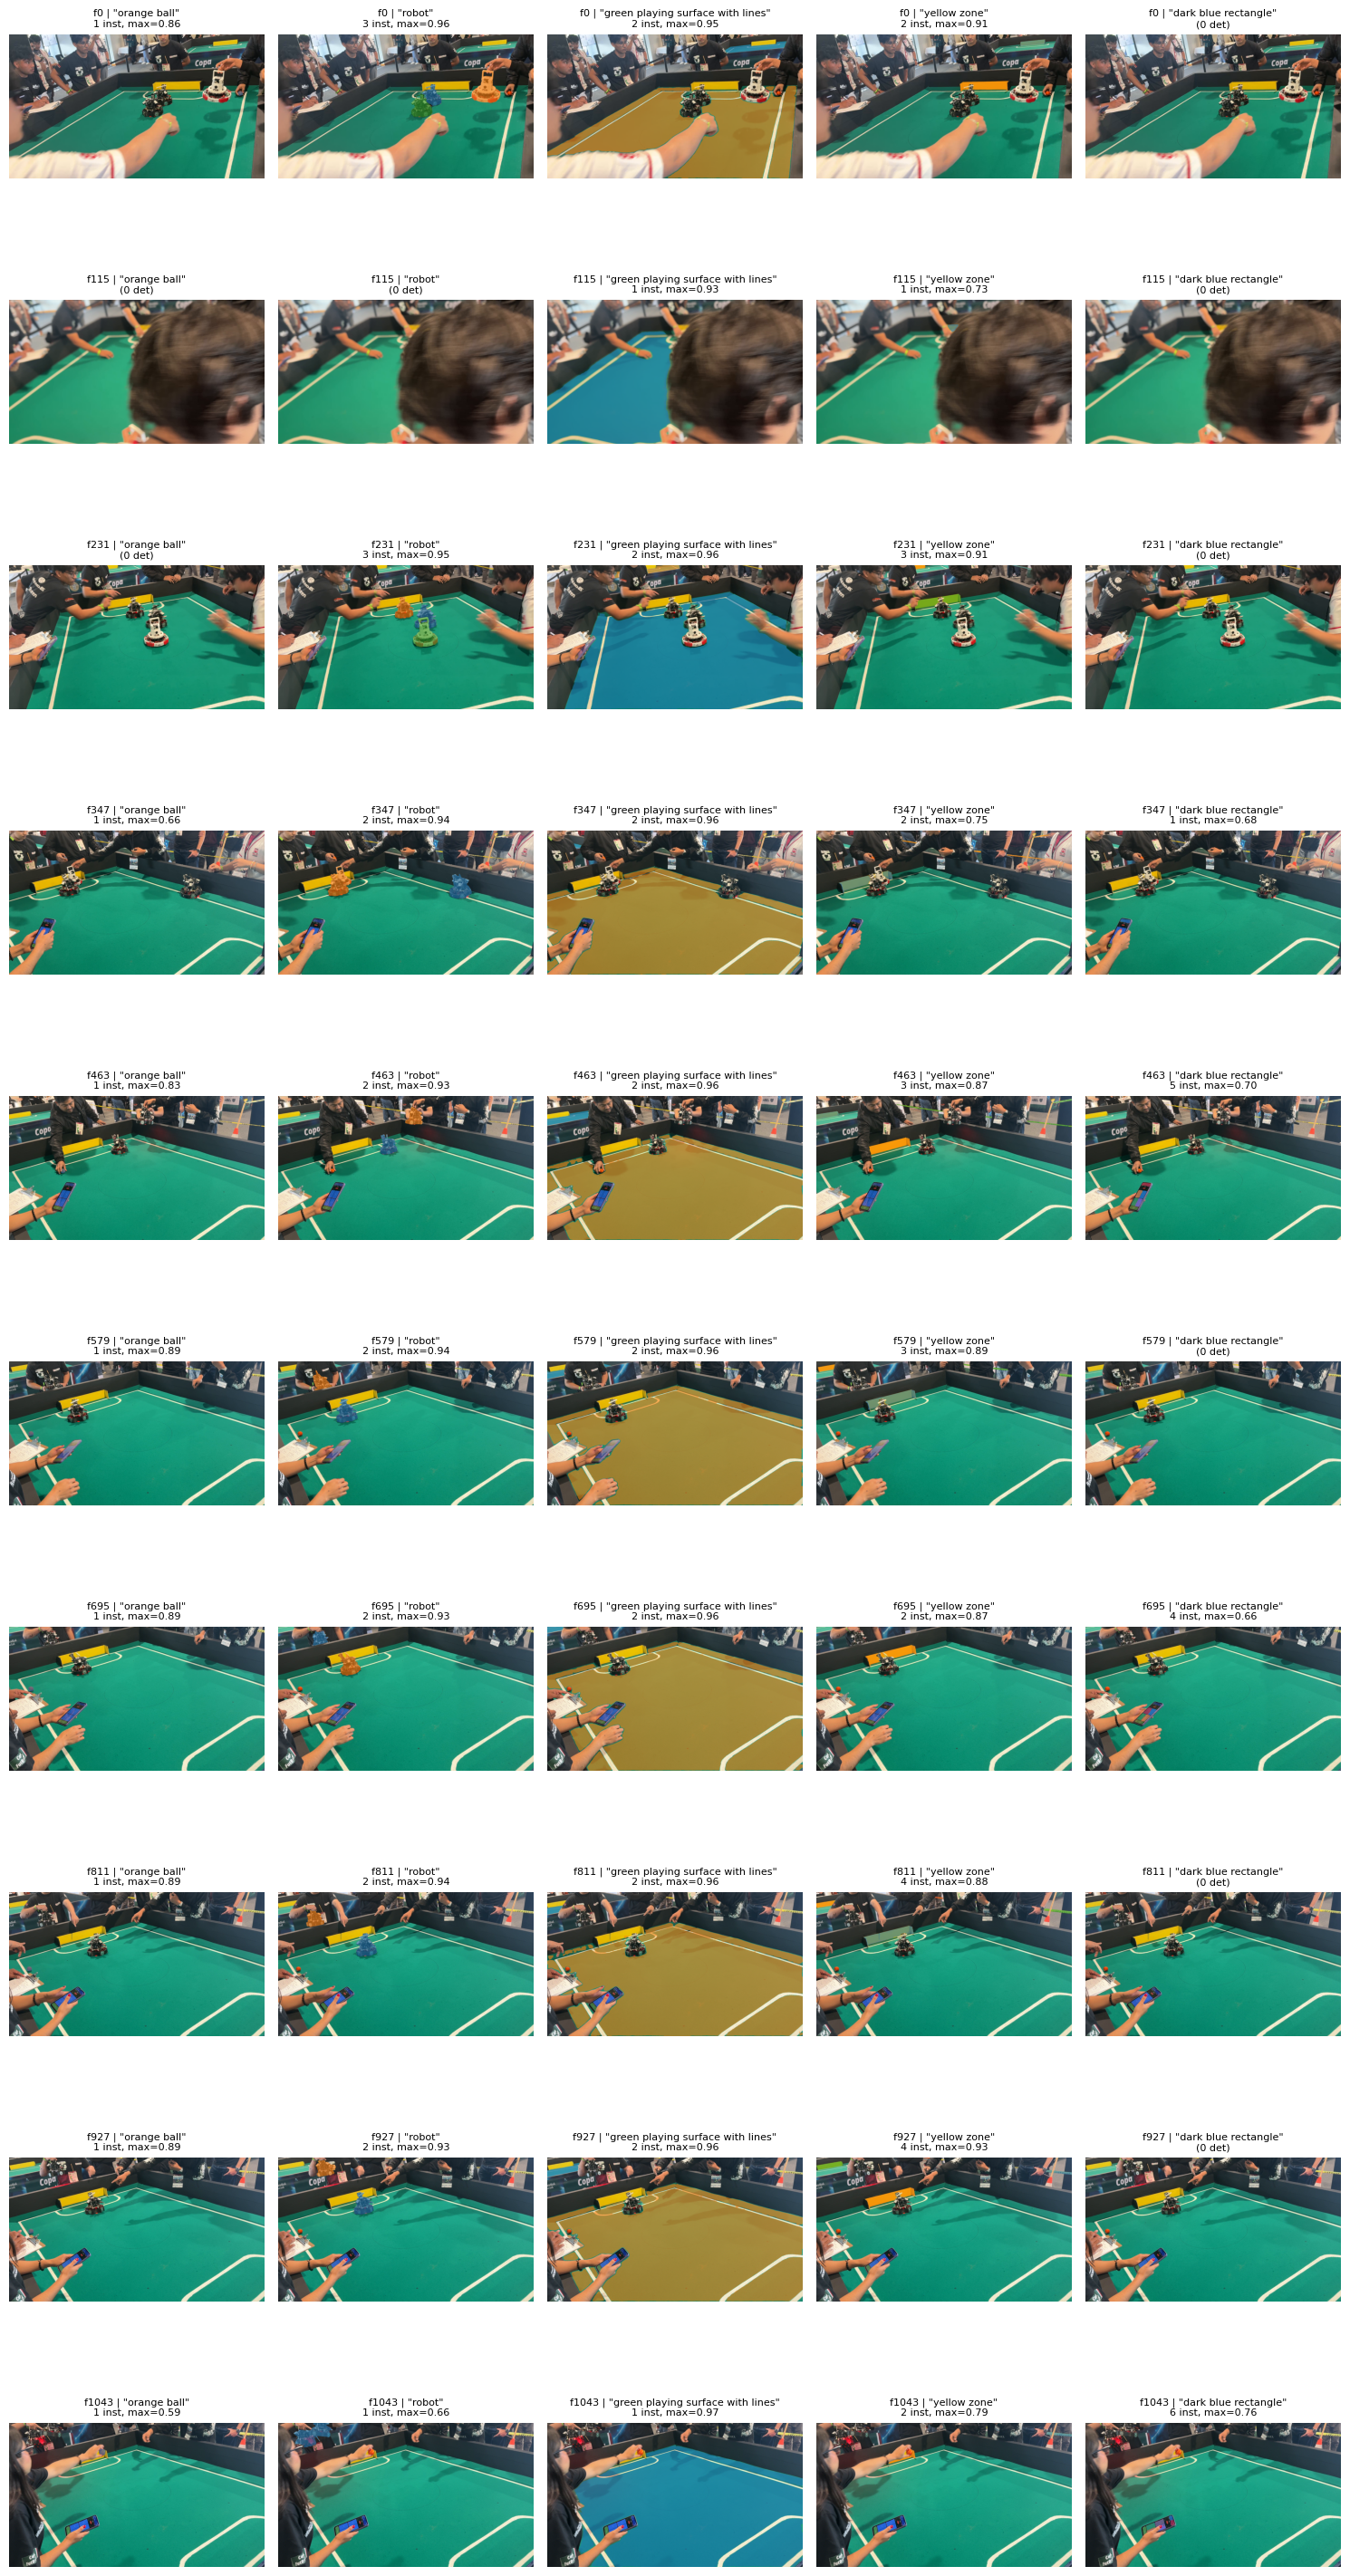

In [9]:
def overlay_masks(image_pil: Image.Image, results):
    img = np.array(image_pil).astype(np.float32) / 255.0
    H, W, _ = img.shape
    overlay = img.copy()
    cmap = plt.get_cmap('tab10')
    for i, (_, mask, _) in enumerate(results):
        if mask.shape != (H, W):
            mask = np.array(Image.fromarray(mask.astype(np.uint8)*255).resize((W, H), Image.NEAREST)) > 0
        color = np.array(cmap(i % 10)[:3])
        overlay[mask] = 0.4 * overlay[mask] + 0.6 * color
    return overlay

n_frames = len(frames_pil)
n_prompts = len(PROMPTS)
fig, axes = plt.subplots(n_frames, n_prompts, figsize=(3*n_prompts, 3*n_frames))
if n_frames == 1:
    axes = np.array([axes])
if n_prompts == 1:
    axes = axes.reshape(-1, 1)

for fi, img in enumerate(frames_pil):
    for pi, prompt in enumerate(PROMPTS):
        res = results_grid[(fi, prompt)]
        ax = axes[fi, pi]
        if not res:
            ax.imshow(img)
            ax.set_title(f'f{FRAME_INDICES[fi]} | "{prompt}"\n(0 det)', fontsize=8)
        else:
            ax.imshow(overlay_masks(img, res))
            best = max(s for _, _, s in res)
            ax.set_title(f'f{FRAME_INDICES[fi]} | "{prompt}"\n{len(res)} inst, max={best:.2f}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

## 10. Próximos pasos

**Lo que valida este notebook:**
- ✅ SAM 3 detecta `"orange ball"` consistente (1 instancia/frame esperada)
- ✅ SAM 3 detecta `"robot"` consistente (varias instancias = todos los robots en cancha)
- ✅ SAM 3 detecta `"green floor"` (la cancha plástica RoboCup)
- ⚠️ Prompts deportivos (`"soccer field"`, `"grass"`) NO funcionan — usar conceptos visuales puros

**Pendiente — Distinguir robots aliados vs enemigos:**
- Opción A: prompts color-based — `"blue robot"`, `"red robot"`, `"yellow robot"` (requiere marcadores visibles en team)
- Opción B: bbox manual (notebook 02) — tú das bbox, SAM 3 segmenta exactamente eso
- Opción C: LoRA fine-tuning (fase_1) — entrenar SAM 3 con tu dataset etiquetado pa' clases custom (`futbotmx_ally`, `futbotmx_enemy`)

**Otros notebooks fase_0:**
- `02_sam3_box_prompt.ipynb` — bbox manual con coords hardcoded (más preciso para objetos pequeños/ambiguos)
- `03_sam3_points_prompt.ipynb` — puntos FG/BG hardcoded
- `04_sam3_video_tracking.ipynb` — tracking continuo (SAM 3 propaga máscara frame a frame en video real)